# ⚡ Practical 2 — From Measurements to Decisions
## Introduction to Python, Pandas and Elering LIVE

Modern power systems are also **data systems**. In this practical we follow one simple chain:

> **measurement → Python → DataFrame → information → decision**

We first use a small Smart Grid dataset, then connect the same ideas to **real Estonian energy data from Elering LIVE**.

### Learning outcomes
By the end you should be able to:
- use simple Python variables, lists and calculations;
- explain `DataFrame` and `Series`;
- inspect rows, columns and data types;
- select columns and filter rows;
- calculate new variables;
- work with timestamps and `groupby()`;
- identify missing data;
- retrieve public price data from Elering;
- use an LLM as an analytical assistant without treating its answer as evidence.

### Working rule
**🤔 THINK → 🐼 TEST → 🤖 ASK → 🧠 JUDGE**

# 0. Elering LIVE: energy data in the real world

Open **https://dashboard.elering.ee/**

Elering is the Estonian transmission system operator. Its public dashboard is a useful example of the Smart Grid logic from Lecture 2:

> **SENSE → COMMUNICATE → DECIDE → ACT**

### Pair discussion — 5 minutes
Explore the dashboard and discuss:
1. What kinds of energy-system variables can you find?
2. Which look like **measurements** and which like **market information**?
3. What units are used?
4. Is everything shown at the same time resolution?
5. Which variables would help answer: Is demand high? Is electricity expensive? Is the system operating normally?

Do not worry if you do not understand every variable yet. Focus on the question: **what can data tell us about an energy system?**

# 1. Python in 10 minutes
A Python **variable** stores a value.

In [ ]:
load_MW = 62.4
solar_MW = 14.2
wind_MW = 11.7
print(load_MW)

62.4


In [ ]:
renewable_MW = solar_MW + wind_MW
net_load_MW = load_MW - renewable_MW
print("Renewable generation:", renewable_MW, "MW")
print("Net load:", net_load_MW, "MW")

Renewable generation: 25.9 MW
Net load: 36.5 MW


### 🐼 Your turn
Create `renewable_share = renewable_MW / load_MW` and print it as a percentage.

In [ ]:
# YOUR CODE HERE

## Lists
A single value is useful, but energy systems produce many measurements.

In [ ]:
loads = [42.1, 45.3, 51.8, 63.2, 58.7]
print(loads)
print("Number of measurements:", len(loads))
print("Maximum:", max(loads))
print("Minimum:", min(loads))

[42.1, 45.3, 51.8, 63.2, 58.7]
Number of measurements: 5
Maximum: 63.2
Minimum: 42.1


A list works for five values. What if we have thousands of meters, prices, weather and sensor data every 15 minutes? This is where tabular data structures become useful.

# 2. Meet the DataFrame
A **Pandas DataFrame** is a two-dimensional table:
- **row** = one observation;
- **column** = one variable;
- **DataFrame** = many observations and variables together.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
example = pd.DataFrame({
    "hour": [8, 9, 10, 11],
    "load_MW": [55.2, 58.1, 52.6, 49.8],
    "solar_MW": [2.1, 5.3, 9.8, 14.5],
})
example

,hour,load_MW,solar_MW
0,8,55.2,2.1
1,9,58.1,5.3
2,10,52.6,9.8
3,11,49.8,14.5


In [ ]:
example["load_MW"]

0    55.2
1    58.1
2    52.6
3    49.8
Name: load_MW, dtype: float64

In [ ]:
example[["hour", "load_MW"]]

,hour,load_MW
0,8,55.2
1,9,58.1
2,10,52.6
3,11,49.8


In [ ]:
print(type(example["load_MW"]))
print(type(example[["load_MW"]]))

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


A single selected column is usually a Pandas **Series**. A table containing one or more columns is a **DataFrame**.

# 3. Our Smart Grid dataset
We create two days of **15-minute synthetic measurements**. The variables are `timestamp`, `load_MW`, `solar_MW`, `wind_MW`, `price_EUR_MWh`, `frequency_Hz`, and `temperature_C`.

In [ ]:
rng = np.random.default_rng(7)
timestamps = pd.date_range("2026-02-09 00:00", periods=2*24*4, freq="15min")
n = len(timestamps)
hour = timestamps.hour.to_numpy() + timestamps.minute.to_numpy()/60

temperature = -3 + 4*np.sin(2*np.pi*(hour-8)/24) + rng.normal(0,0.6,n)
morning_peak = 180*np.exp(-0.5*((hour-8)/1.8)**2)
evening_peak = 260*np.exp(-0.5*((hour-18)/2.0)**2)
load = 720 + morning_peak + evening_peak + np.clip(-temperature,0,None)*12 + rng.normal(0,18,n)

solar_shape = 330*np.exp(-0.5*((hour-12.5)/2.6)**2)
daylight = ((hour>=7.5)&(hour<=17.0)).astype(float)
solar = solar_shape*daylight*np.clip(rng.normal(0.78,0.10,n),0.35,1.0)

wind = 190 + 75*np.sin(np.linspace(0,4*np.pi,n)) + rng.normal(0,28,n)
wind = np.clip(wind,20,None)
wind_drop = (timestamps >= "2026-02-10 16:30") & (timestamps <= "2026-02-10 19:00")
wind[wind_drop] *= 0.30

net_for_price = load - solar - wind
price = 35 + 0.10*np.clip(net_for_price,0,None) + rng.normal(0,5,n)
price[timestamps == pd.Timestamp("2026-02-10 18:00")] += 110

frequency = 50 + rng.normal(0,0.018,n)
freq_event = (timestamps >= "2026-02-10 18:00") & (timestamps <= "2026-02-10 18:30")
frequency[freq_event] -= 0.10

df = pd.DataFrame({
    "timestamp": timestamps,
    "load_MW": load.round(1),
    "solar_MW": solar.round(1),
    "wind_MW": wind.round(1),
    "price_EUR_MWh": price.round(2),
    "frequency_Hz": frequency.round(3),
    "temperature_C": temperature.round(1),
})

df.loc[[17,18], "wind_MW"] = np.nan
df.loc[[103], "temperature_C"] = np.nan
df.head()

,timestamp,load_MW,solar_MW,wind_MW,price_EUR_MWh,frequency_Hz,temperature_C
0,2026-02-09 00:00:00,815.0,0.0,153.7,108.90,50.033,-6.5
1,2026-02-09 00:15:00,794.4,0.0,177.2,93.33,50.031,-6.4
2,2026-02-09 00:30:00,812.1,0.0,235.5,93.08,49.965,-6.9
3,2026-02-09 00:45:00,822.0,0.0,194.3,95.17,49.983,-7.3
4,2026-02-09 01:00:00,820.7,0.0,217.1,102.81,50.012,-7.1


# 4. First inspection
Before analysing data, ask: **what exactly do I have?**

In [ ]:
df.head()

,timestamp,load_MW,solar_MW,wind_MW,price_EUR_MWh,frequency_Hz,temperature_C
0,2026-02-09 00:00:00,815.0,0.0,153.7,108.90,50.033,-6.5
1,2026-02-09 00:15:00,794.4,0.0,177.2,93.33,50.031,-6.4
2,2026-02-09 00:30:00,812.1,0.0,235.5,93.08,49.965,-6.9
3,2026-02-09 00:45:00,822.0,0.0,194.3,95.17,49.983,-7.3
4,2026-02-09 01:00:00,820.7,0.0,217.1,102.81,50.012,-7.1


In [ ]:
df.shape

(192, 7)

In [ ]:
df.columns

Index(['timestamp', 'load_MW', 'solar_MW', 'wind_MW', 'price_EUR_MWh',
       'frequency_Hz', 'temperature_C'],
      dtype='object')

In [ ]:
df.dtypes

timestamp        datetime64[ns]
load_MW                 float64
solar_MW                float64
wind_MW                 float64
price_EUR_MWh           float64
frequency_Hz            float64
temperature_C           float64
dtype: object

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      192 non-null    datetime64[ns]
 1   load_MW        192 non-null    float64       
 2   solar_MW       192 non-null    float64       
 3   wind_MW        190 non-null    float64       
 4   price_EUR_MWh  192 non-null    float64       
 5   frequency_Hz   192 non-null    float64       
 6   temperature_C  191 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 10.6 KB


### 🐼 Your turn
Answer: How many rows and columns? Which column contains time? Which are numerical? Does every column have the same number of non-missing values?

# 5. Descriptive statistics

In [ ]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
timestamp,192,2026-02-09 23:52:30,2026-02-09 00:00:00,2026-02-09 11:56:15,2026-02-09 23:52:30,2026-02-10 11:48:45,2026-02-10 23:45:00,NaN
load_MW,192.0,846.267188,708.7,795.625,831.2,900.175,1025.9,74.132742
solar_MW,192.0,63.023438,0.0,0.0,0.0,129.075,274.9,87.518253
wind_MW,190.0,185.410526,20.4,133.9,192.9,236.8,335.9,67.50366
price_EUR_MWh,192.0,95.288958,56.91,85.995,94.99,104.15,238.33,19.462509
frequency_Hz,192.0,49.997615,49.887,49.986,49.999,50.012,50.045,0.022681
temperature_C,191.0,-3.084817,-8.0,-5.9,-3.3,-0.3,1.8,2.917701


In [ ]:
print("Mean load:", df["load_MW"].mean(), "MW")
print("Maximum load:", df["load_MW"].max(), "MW")
print("Minimum frequency:", df["frequency_Hz"].min(), "Hz")
print("Maximum price:", df["price_EUR_MWh"].max(), "EUR/MWh")

Mean load: 846.2671875000001 MW
Maximum load: 1025.9 MW
Minimum frequency: 49.887 Hz
Maximum price: 238.33 EUR/MWh


### 🐼 Your turn
Find mean solar generation, maximum wind generation, and minimum electricity price using `.mean()`, `.max()`, `.min()`.

In [ ]:
# YOUR CODE HERE

# 6. Selecting data

In [ ]:
df["load_MW"].head()

0    815.0
1    794.4
2    812.1
3    822.0
4    820.7
Name: load_MW, dtype: float64

In [ ]:
df[["timestamp", "load_MW", "price_EUR_MWh"]].head()

,timestamp,load_MW,price_EUR_MWh
0,2026-02-09 00:00:00,815.0,108.90
1,2026-02-09 00:15:00,794.4,93.33
2,2026-02-09 00:30:00,812.1,93.08
3,2026-02-09 00:45:00,822.0,95.17
4,2026-02-09 01:00:00,820.7,102.81


### 🐼 Your turn
Create `renewable_view` with only `timestamp`, `solar_MW`, `wind_MW`, then show the first 10 rows.

In [ ]:
# YOUR CODE HERE

# 7. Filtering: find important moments
Filtering asks: **which rows satisfy a condition?**

In [ ]:
high_load = df[df["load_MW"] > 1000]
high_load.head()

,timestamp,load_MW,solar_MW,wind_MW,price_EUR_MWh,frequency_Hz,temperature_C
71,2026-02-09 17:45:00,1005.5,0.0,101.8,114.88,49.994,-2.0
73,2026-02-09 18:15:00,1002.6,0.0,108.6,122.34,50.010,-1.3
168,2026-02-10 18:00:00,1001.2,0.0,50.0,238.33,49.888,-1.0
169,2026-02-10 18:15:00,1025.9,0.0,51.3,137.12,49.903,-1.2
170,2026-02-10 18:30:00,1005.7,0.0,46.0,136.93,49.887,-1.9


In [ ]:
low_frequency = df[df["frequency_Hz"] < 49.95]
low_frequency[["timestamp", "frequency_Hz", "load_MW", "price_EUR_MWh"]]

,timestamp,frequency_Hz,load_MW,price_EUR_MWh
168,2026-02-10 18:00:00,49.888,1001.2,238.33
169,2026-02-10 18:15:00,49.903,1025.9,137.12
170,2026-02-10 18:30:00,49.887,1005.7,136.93


In [ ]:
stress = df[(df["load_MW"] > 950) & (df["wind_MW"] < 120)]
stress[["timestamp", "load_MW", "wind_MW", "price_EUR_MWh"]]

,timestamp,load_MW,wind_MW,price_EUR_MWh
71,2026-02-09 17:45:00,1005.5,101.8,114.88
73,2026-02-09 18:15:00,1002.6,108.6,122.34
75,2026-02-09 18:45:00,997.6,91.3,124.70
76,2026-02-09 19:00:00,952.5,94.2,111.96
165,2026-02-10 17:15:00,970.5,29.6,135.40
166,2026-02-10 17:30:00,995.2,20.4,131.99
167,2026-02-10 17:45:00,980.5,34.3,123.12
168,2026-02-10 18:00:00,1001.2,50.0,238.33
169,2026-02-10 18:15:00,1025.9,51.3,137.12
170,2026-02-10 18:30:00,1005.7,46.0,136.93


### 🚨 Grid Alert — your turn
Find rows with `price_EUR_MWh > 120`. Then find rows with `load_MW > 950` **and** `solar_MW < 30`. Which condition produces more observations?

In [ ]:
# YOUR CODE HERE

# 8. From measurements to information
The operator may care about quantities that are not directly measured.

`renewable = solar + wind`

`net_load = load - renewable`

In [ ]:
df["renewable_MW"] = df["solar_MW"] + df["wind_MW"]
df["net_load_MW"] = df["load_MW"] - df["renewable_MW"]
df["renewable_share_pct"] = 100*df["renewable_MW"]/df["load_MW"]
df[["timestamp","load_MW","renewable_MW","net_load_MW","renewable_share_pct"]].head()

,timestamp,load_MW,renewable_MW,net_load_MW,renewable_share_pct
0,2026-02-09 00:00:00,815.0,153.7,661.3,18.858896
1,2026-02-09 00:15:00,794.4,177.2,617.2,22.306143
2,2026-02-09 00:30:00,812.1,235.5,576.6,28.998892
3,2026-02-09 00:45:00,822.0,194.3,627.7,23.637470
4,2026-02-09 01:00:00,820.7,217.1,603.6,26.453028


### Discussion
Which variables are **raw measurements** and which are **derived information**? This is a small example of turning measurements into information.

### 🐼 Your turn
Use `df.nlargest(5, "net_load_MW")` to find the five most demanding periods for non-renewable supply.

In [ ]:
# YOUR CODE HERE

# 9. Energy data has time
The lecture ends with an important idea: **energy data is mostly time series**.

In [ ]:
df["timestamp"].dtype

dtype('<M8[ns]')

In [ ]:
df["hour"] = df["timestamp"].dt.hour
df["date"] = df["timestamp"].dt.date
df["day_name"] = df["timestamp"].dt.day_name()
df[["timestamp","hour","date","day_name"]].head()

,timestamp,hour,date,day_name
0,2026-02-09 00:00:00,0,2026-02-09,Monday
1,2026-02-09 00:15:00,0,2026-02-09,Monday
2,2026-02-09 00:30:00,0,2026-02-09,Monday
3,2026-02-09 00:45:00,0,2026-02-09,Monday
4,2026-02-09 01:00:00,1,2026-02-09,Monday


# 10. GroupBy: discover a daily pattern
`groupby()` means: split observations into groups → calculate something for each group.

In [ ]:
hourly_load = df.groupby("hour", as_index=False)["load_MW"].mean()
hourly_load

,hour,load_MW
0,0,806.7750
1,1,814.7500
2,2,807.8625
3,3,811.6750
4,4,830.7750
5,5,842.3750
6,6,892.9125
7,7,925.9125
8,8,927.1250
9,9,862.9125


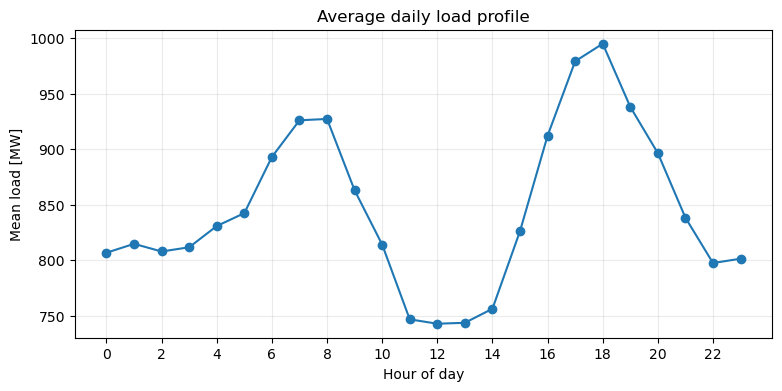

In [ ]:
plt.figure(figsize=(9,4))
plt.plot(hourly_load["hour"], hourly_load["load_MW"], marker="o")
plt.xlabel("Hour of day")
plt.ylabel("Mean load [MW]")
plt.title("Average daily load profile")
plt.xticks(range(0,24,2))
plt.grid(alpha=0.25)
plt.show()

### 🤔 THINK → 🐼 TEST
Do you expect one daily peak or two? At what hours? Then use the DataFrame to identify the hour with the highest mean load.

In [ ]:
# YOUR CODE HERE

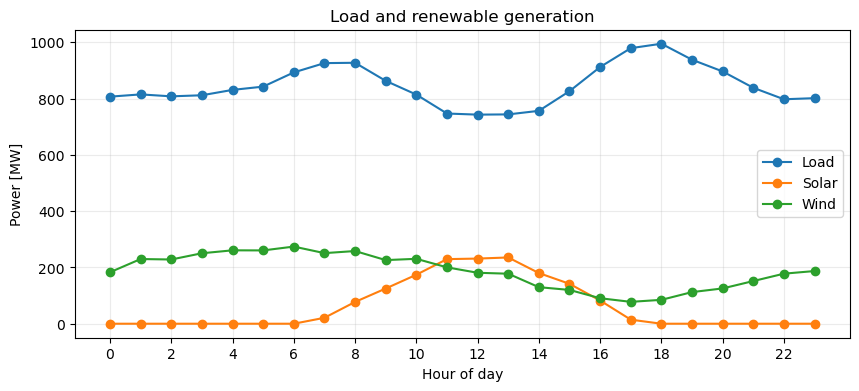

In [ ]:
hourly_energy = df.groupby("hour", as_index=False)[["load_MW","solar_MW","wind_MW"]].mean()
plt.figure(figsize=(10,4))
plt.plot(hourly_energy["hour"], hourly_energy["load_MW"], marker="o", label="Load")
plt.plot(hourly_energy["hour"], hourly_energy["solar_MW"], marker="o", label="Solar")
plt.plot(hourly_energy["hour"], hourly_energy["wind_MW"], marker="o", label="Wind")
plt.xlabel("Hour of day")
plt.ylabel("Power [MW]")
plt.title("Load and renewable generation")
plt.legend()
plt.xticks(range(0,24,2))
plt.grid(alpha=0.25)
plt.show()

### Discussion
Does renewable generation peak at the same time as demand? How does this connect to **peak demand** and **renewable volatility** from the lecture?

# 11. Missing data
Real sensors and communication systems do not always produce perfect datasets.

In [ ]:
df.isna().sum()

timestamp              0
load_MW                0
solar_MW               0
wind_MW                2
price_EUR_MWh          0
frequency_Hz           0
temperature_C          1
renewable_MW           2
net_load_MW            2
renewable_share_pct    2
hour                   0
date                   0
day_name               0
dtype: int64

In [ ]:
df[df["wind_MW"].isna()]

,timestamp,load_MW,solar_MW,wind_MW,price_EUR_MWh,frequency_Hz,temperature_C,renewable_MW,net_load_MW,renewable_share_pct,hour,date,day_name
17,2026-02-09 04:15:00,801.5,0.0,NaN,76.97,49.984,-6.6,NaN,NaN,NaN,4,2026-02-09,Monday
18,2026-02-09 04:30:00,834.7,0.0,NaN,89.04,50.007,-7.3,NaN,NaN,NaN,4,2026-02-09,Monday


### Discussion
Why could a measurement be missing? Think about sensor problems, communication failures, maintenance, database issues and processing errors. Today we only **detect** missing data; later we will learn how to handle it.

# 12. LLM checkpoint — interpretation is not evidence

In [ ]:
summary_for_llm = df[["load_MW","solar_MW","wind_MW","price_EUR_MWh","frequency_Hz"]].describe().round(2)
summary_for_llm

,load_MW,solar_MW,wind_MW,price_EUR_MWh,frequency_Hz
count,192.00,192.00,190.00,192.00,192.00
mean,846.27,63.02,185.41,95.29,50.00
std,74.13,87.52,67.50,19.46,0.02
min,708.70,0.00,20.40,56.91,49.89
25%,795.62,0.00,133.90,86.00,49.99
50%,831.20,0.00,192.90,94.99,50.00
75%,900.18,129.07,236.80,104.15,50.01
max,1025.90,274.90,335.90,238.33,50.04


Copy the table into an LLM and ask:

```text
You are assisting a junior energy analyst.
I will provide summary statistics from a power-system dataset.
1. Give three observations directly supported by the table.
2. Give three hypotheses that require further testing.
3. Do not invent events or causal explanations.
4. Clearly label OBSERVATION and HYPOTHESIS.
```

### 🧠 JUDGE
Did the LLM infer temporal patterns from statistics that contain no time information? Did it confuse coincidence with cause? **LLM output is a hypothesis until checked against data.**

# 13. Real data: Elering public API
Now we move from synthetic data to a real public source. Elering Dashboard provides a public Nord Pool price endpoint for the Estonian price area.

The code below requests the **last complete local day in Estonia**, converts JSON into a DataFrame, and analyses it. No API key is required for this price endpoint.

> Internet access is required. If the request fails, the notebook creates fallback data so the Pandas exercise still works.

In [ ]:
import requests

local_start = pd.Timestamp.now(tz="Europe/Tallinn").normalize() - pd.Timedelta(days=1)
local_end = local_start + pd.Timedelta(days=1)
start_utc = local_start.tz_convert("UTC")
end_utc = local_end.tz_convert("UTC") - pd.Timedelta(milliseconds=1)

def iso_z(ts):
    return ts.strftime("%Y-%m-%dT%H:%M:%S.000Z")

url = "https://dashboard.elering.ee/api/nps/price"
params = {"start": iso_z(start_utc), "end": iso_z(end_utc)}
print("Local date:", local_start.date())
print("UTC window:", params["start"], "→", params["end"])

Local date: 2026-09-03
UTC window: 2026-09-02T21:00:00.000Z → 2026-09-03T20:59:59.000Z


In [ ]:
try:
    response = requests.get(url, params=params, timeout=20)
    response.raise_for_status()
    payload = response.json()
    records = payload["data"]["ee"]
    elering = pd.DataFrame(records)
    elering["timestamp"] = pd.to_datetime(elering["timestamp"], unit="s", utc=True).dt.tz_convert("Europe/Tallinn")
    elering = elering[["timestamp","price"]].rename(columns={"price":"price_EUR_MWh"})
    DATA_SOURCE = "LIVE ELERING API"
except Exception as exc:
    print("Live API request failed:", exc)
    print("Using fallback data.")
    fallback_time = pd.date_range("2026-08-19 00:00", periods=24*4, freq="15min", tz="Europe/Tallinn")
    h = fallback_time.hour.to_numpy() + fallback_time.minute.to_numpy()/60
    fallback_price = 55 + 20*np.sin(2*np.pi*(h-7)/24) + 45*np.exp(-0.5*((h-20)/2.0)**2)
    elering = pd.DataFrame({"timestamp":fallback_time, "price_EUR_MWh":fallback_price.round(2)})
    DATA_SOURCE = "FALLBACK DATA"

print("Data source:", DATA_SOURCE)
elering.head()

Data source: LIVE ELERING API


,timestamp,price_EUR_MWh
0,2026-09-03 00:00:00+03:00,38.26
1,2026-09-03 00:15:00+03:00,34.36
2,2026-09-03 00:30:00+03:00,29.63
3,2026-09-03 00:45:00+03:00,26.08
4,2026-09-03 01:00:00+03:00,26.15


## Inspect the real DataFrame

In [ ]:
print("Shape:", elering.shape)
print(elering.dtypes)
display(elering.describe().T.round(2))

Shape: (96, 2)
timestamp        datetime64[ns, Europe/Tallinn]
price_EUR_MWh                           float64
dtype: object


,count,mean,std,min,25%,50%,75%,max
price_EUR_MWh,96.0,51.33,37.05,16.0,26.13,38.66,51.97,158.19


## Do not assume the sampling interval
Different energy datasets have different sampling rates. Let the data tell us the interval.

In [ ]:
time_differences = elering["timestamp"].sort_values().diff().dropna()
print(time_differences.value_counts().head())

timestamp
0 days 00:15:00    95
Name: count, dtype: int64


### 🐼 Your turn — real Elering data
Use Pandas to find: minimum price, maximum price, mean price, timestamp of the maximum, and number of observations above `100 EUR/MWh`.

In [ ]:
# YOUR CODE HERE

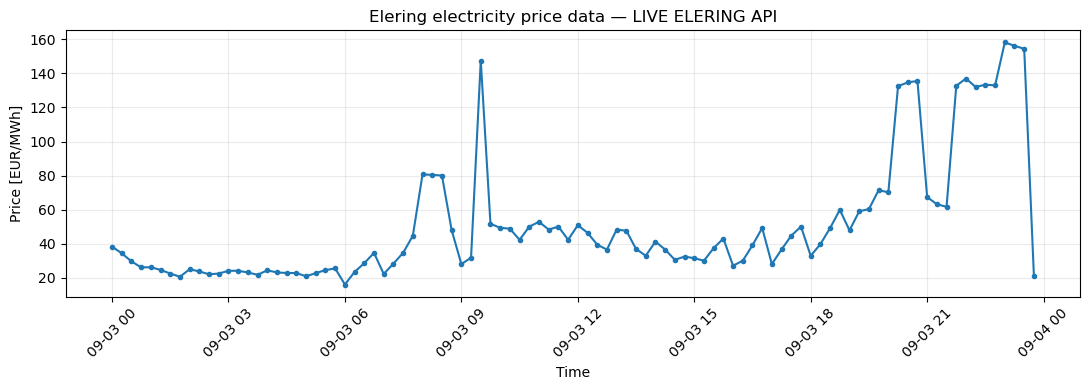

In [ ]:
plt.figure(figsize=(11,4))
plt.plot(elering["timestamp"], elering["price_EUR_MWh"], marker=".")
plt.xlabel("Time")
plt.ylabel("Price [EUR/MWh]")
plt.title(f"Elering electricity price data — {DATA_SOURCE}")
plt.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 14. A tiny Demand Response question
Imagine an EV needs **1 hour of charging**. If the price data use 15-minute intervals, one hour corresponds to four observations. Find the four cheapest observations:

In [ ]:
cheapest = elering.nsmallest(4, "price_EUR_MWh")
cheapest

,timestamp,price_EUR_MWh
24,2026-09-03 06:00:00+03:00,16.00
7,2026-09-03 01:45:00+03:00,20.56
20,2026-09-03 05:00:00+03:00,20.81
95,2026-09-03 23:45:00+03:00,21.12


### Discussion
Is selecting the four individually cheapest intervals necessarily a good charging schedule? What else do we need to know: consecutive intervals, EV connection time, charging power, departure time, user preference? This is the difference between **finding information** and **making an operational decision**.

# 15. Final challenge — SENSE → DECIDE → ACT
Work in pairs. Identify one period in the synthetic dataset that deserves attention.

### SENSE
Find a period with high demand, low renewable generation, high price, or unusual frequency.

### DECIDE
Calculate at least **two numerical indicators** and create one useful plot or filtered table.

### ASK
Ask an LLM:
```text
You are assisting a power-system operator.
Here are the measurements and indicators I selected:
[paste evidence]
Suggest two possible actions. For each action explain why it may help, list assumptions, and state what additional data are needed. Do not claim that an action is optimal or safe without further validation.
```

### JUDGE
Which recommendation is actually supported by your data?

### ACT
Prepare a 60-second briefing:
**We observed ... The evidence is ... We recommend investigating/considering ... Before acting, we still need ...**

In [ ]:
# YOUR ANALYSIS HERE

# 16. Reflection
### Python & Pandas
1. What is a variable?
2. What is a list?
3. What is a DataFrame?
4. What is the difference between a row and a column?
5. What does filtering do?
6. What does `groupby()` do?

### Energy Informatics
7. Give one example of a measurement and one example of derived information.
8. Why can renewable variability make operation harder?
9. Why do missing measurements matter?

### Elering
10. What did the Elering dashboard show that connects to Lecture 2?
11. What was the time resolution of the price data you retrieved?
12. Why should you check time resolution instead of assuming it?

### LLM
13. What was the LLM useful for?
14. What still had to be verified with data?

